# Solution 4C: Monthly Spearman Rank Correlation
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from scipy.stats import spearmanr

df = pd.read_parquet("merged.parquet")
df = df[df["month"] >= "2023-01"].copy()

FEATURES = ["momentum", "lag_month", "pb", "roe", "grossmargin",
            "assetturnover", "leverage", "asset_growth", "gp_to_assets"]

for feat in FEATURES:
    df[f"{feat}_rank"] = df.groupby("month")[feat].transform(lambda x: x.rank(pct=True))
df["ret_rank"] = df.groupby("month")["return"].transform(lambda x: x.rank(pct=True))
feat_cols = [f"{f}_rank" for f in FEATURES]
months = sorted(df["month"].unique())
print(f"Data: {len(df):,} rows, {len(months)} months ({months[0]} to {months[-1]})")

Data: 103,931 rows, 35 months (2023-01 to 2025-11)


In [2]:
def run_backtest(df, months, feat_cols, start_month="2024-01", window=None):
    start_idx = next(i for i, m in enumerate(months) if m >= start_month)
    all_preds = []
    for t in range(start_idx, len(months)):
        test_month = months[t]
        if window is None:
            train_data = df[df["month"] < test_month]
        else:
            train_start_idx = max(0, t - window)
            train_months = months[train_start_idx:t]
            train_data = df[df["month"].isin(train_months)]
        test_data = df[df["month"] == test_month]
        if len(train_data) < 100 or len(test_data) < 10:
            continue
        model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                                  random_state=42, verbosity=-1, n_jobs=-1)
        model.fit(train_data[feat_cols].values, train_data["ret_rank"].values)
        result = test_data[["ticker", "month", "return", "ret_rank", "marketcap"]].copy()
        result["pred"] = model.predict(test_data[feat_cols].values)
        all_preds.append(result)
        print(f"  Predicted {test_month} (train: {len(train_data):,} rows)")
    return pd.concat(all_preds, ignore_index=True)

## Setup: Run both backtests

In [3]:
preds_exp = run_backtest(df, months, feat_cols, start_month="2024-01", window=None)
preds_roll = run_backtest(df, months, feat_cols, start_month="2024-01", window=12)

  Predicted 2024-01 (train: 37,810 rows)


  Predicted 2024-02 (train: 40,875 rows)


  Predicted 2024-03 (train: 43,892 rows)


  Predicted 2024-04 (train: 46,935 rows)


  Predicted 2024-05 (train: 49,980 rows)


...

  Predicted 2025-07 (train: 34,319 rows)


  Predicted 2025-08 (train: 34,111 rows)


  Predicted 2025-09 (train: 33,873 rows)


  Predicted 2025-10 (train: 33,697 rows)


  Predicted 2025-11 (train: 33,536 rows)


## 1-3. Spearman correlations

In [4]:
def monthly_spearman(preds_df):
    result = {}
    for m, grp in preds_df.groupby("month"):
        if len(grp) > 10:
            rho, _ = spearmanr(grp["pred"], grp["return"])
            result[m] = rho
    return pd.Series(result).sort_index()

sp_exp = monthly_spearman(preds_exp)
sp_roll = monthly_spearman(preds_roll)

for label, sp in [("Expanding", sp_exp), ("Rolling", sp_roll)]:
    print(f"{label}:")
    print(f"  Mean: {sp.mean():.4f}, Median: {sp.median():.4f}, "
          f"Std: {sp.std():.4f}, Frac +: {(sp > 0).mean():.2%}")

Expanding:
  Mean: 0.0937, Median: 0.0967, Std: 0.0899, Frac +: 82.61%
Rolling:
  Mean: 0.0916, Median: 0.1105, Std: 0.0895, Frac +: 82.61%


## 4. Best and worst months

In [5]:
if len(sp_exp) >= 3:
    print("Expanding - Top 3:", sp_exp.nlargest(3).to_dict())
    print("Expanding - Bottom 3:", sp_exp.nsmallest(3).to_dict())

Expanding - Top 3: {'2025-02': 0.23165882510625677, '2024-06': 0.2153301074551081, '2024-07': 0.1989707339992085}
Expanding - Bottom 3: {'2025-09': -0.05368387395836101, '2024-12': -0.05313885466056328, '2025-10': -0.033315961993095916}


Months with very low Spearman correlations may coincide with market stress or regime shifts.

## 5. Overlay plot

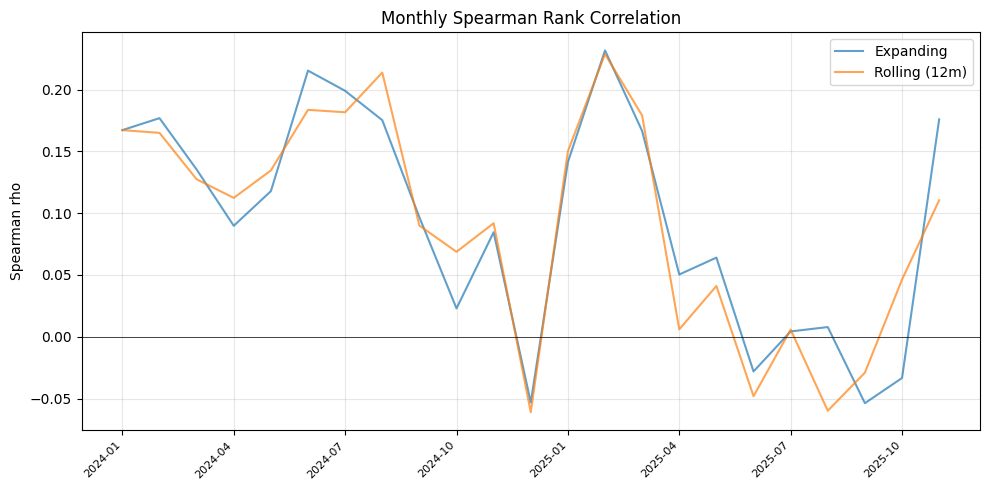

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(sp_exp)), sp_exp.values, label="Expanding", alpha=0.7)
ax.plot(range(len(sp_roll.reindex(sp_exp.index))), sp_roll.reindex(sp_exp.index).values,
        label="Rolling (12m)", alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Monthly Spearman Rank Correlation")
ax.set_ylabel("Spearman rho")
ax.legend()
ax.grid(True, alpha=0.3)
ticks = list(range(0, len(sp_exp), max(1, len(sp_exp) // 6)))
ax.set_xticks(ticks)
ax.set_xticklabels([sp_exp.index[i] for i in ticks], rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()